## Imports

In [172]:
import math
from datetime import date, timedelta
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060


## Geração do dataset


In [173]:
import random
from datetime import date

ANO_MIN = 1
ANO_MAX = 9999
N_EXEMPLOS = 100_000

MESES = {
    1: "janeiro",
    2: "fevereiro",
    3: "março",
    4: "abril",
    5: "maio",
    6: "junho",
    7: "julho",
    8: "agosto",
    9: "setembro",
    10: "outubro",
    11: "novembro",
    12: "dezembro",
}


def gerar_data_aleatoria():
    while True:
        ano = random.randint(ANO_MIN, ANO_MAX)
        mes = random.randint(1, 12)
        dia = random.randint(1, 31)

        try:
            return date(ano, mes, dia)
        except ValueError:
            continue


def gerar_entradas(data_obj):
    dia = data_obj.day
    mes = data_obj.month
    ano = data_obj.year
    mes_nome = MESES[mes]

    return [
        f"{dia:02d}/{mes:02d}/{ano:04d}",
        f"{dia} de {mes_nome} de {ano:04d}",
        f"dia {dia} de {mes_nome} de {ano:04d}",
    ]


def gerar_dataset(n_exemplos=100_000):
    dados = []

    for _ in range(n_exemplos):
        data_obj = gerar_data_aleatoria()
        saida = data_obj.isoformat()

        entrada = random.choice(gerar_entradas(data_obj))

        dados.append({
            "entrada": entrada,
            "saida": saida,
            "texto": f"{entrada} => {saida}",
        })

    return pd.DataFrame(dados).drop_duplicates().reset_index(drop=True)


df = gerar_dataset(N_EXEMPLOS)

print("Dataset gerado.")
print("Total:", len(df))

display(df.head())

Dataset gerado.
Total: 99527


,entrada,saida,texto
0,29/12/0648,0648-12-29,29/12/0648 => 0648-12-29
1,12/07/1998,1998-07-12,12/07/1998 => 1998-07-12
2,24/04/5773,5773-04-24,24/04/5773 => 5773-04-24
3,21 de fevereiro de 1607,1607-02-21,21 de fevereiro de 1607 => 1607-02-21
4,06/12/6234,6234-12-06,06/12/6234 => 6234-12-06


## Separaçao dos datasets de treino e teste

In [174]:
datas_unicas = df["saida"].drop_duplicates()

datas_train, datas_test = train_test_split(
    datas_unicas,
    test_size=0.20,
    shuffle=True
)

train_df = df[df["saida"].isin(datas_train)].reset_index(drop=True)
test_df = df[df["saida"].isin(datas_test)].reset_index(drop=True)

print("Tamanhos dos conjuntos:")
print("Treino:", len(train_df), "exemplos -", train_df["saida"].nunique(), "datas únicas")
print("Teste:", len(test_df), "exemplos -", test_df["saida"].nunique(), "datas únicas")

display(train_df.head())
display(test_df.head())

Tamanhos dos conjuntos:
Treino: 79622 exemplos - 78853 datas únicas
Teste: 19905 exemplos - 19714 datas únicas


,entrada,saida,texto
0,29/12/0648,0648-12-29,29/12/0648 => 0648-12-29
1,12/07/1998,1998-07-12,12/07/1998 => 1998-07-12
2,24/04/5773,5773-04-24,24/04/5773 => 5773-04-24
3,21 de fevereiro de 1607,1607-02-21,21 de fevereiro de 1607 => 1607-02-21
4,06/12/6234,6234-12-06,06/12/6234 => 6234-12-06


,entrada,saida,texto
0,31 de janeiro de 9880,9880-01-31,31 de janeiro de 9880 => 9880-01-31
1,27 de maio de 7768,7768-05-27,27 de maio de 7768 => 7768-05-27
2,2 de maio de 2859,2859-05-02,2 de maio de 2859 => 2859-05-02
3,3 de setembro de 8986,8986-09-03,3 de setembro de 8986 => 8986-09-03
4,dia 3 de maio de 3014,3014-05-03,dia 3 de maio de 3014 => 3014-05-03


## Definicoes ed vocabulario

In [175]:
PAD_TOKEN = "<PAD>"

vocab_chars = sorted(set("".join(df["texto"].tolist())))
vocab = [PAD_TOKEN] + vocab_chars

stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}

PAD_IDX = stoi[PAD_TOKEN]
VOCAB_SIZE = len(vocab)

print("Tamanho do vocabulário:", VOCAB_SIZE)
print("Vocabulário:", vocab)

Tamanho do vocabulário: 36
Vocabulário: ['<PAD>', ' ', '-', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '>', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u', 'v', 'z', 'ç']


# Transformer

## Configuracoes

In [176]:
BLOCK_SIZE = 64

D_MODEL = 64
N_LAYERS = 2
DROPOUT = 0.1

BATCH_SIZE = 256
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 50
PATIENCE = 10

In [177]:
def masked_loss(logits, targets, loss_mask):
    vocab_size = logits.size(-1)

    loss_por_token = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=PAD_IDX,
        reduction="none"
    )

    loss_mask = loss_mask.reshape(-1)

    return (loss_por_token * loss_mask).sum() / loss_mask.sum().clamp(min=1)

## Flat Attention

In [178]:
class FlatAttention(nn.Module):
    def __init__(self, d_model, block_size, dropout=0.1):
        super().__init__()

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)

        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = q @ k.transpose(-2, -1)
        scores = scores / math.sqrt(C)

        scores = scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = attn @ v
        out = self.proj(out)
        out = self.dropout(out)

        return out

## Feed Forward

In [179]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

## Bloco Transformer

X -> LayerNorm -> Attention -> Residual -> LayerNorm -> FF -> Residual

In [180]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, block_size, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)

        self.attn = FlatAttention(
            d_model=d_model,
            block_size=block_size,
            dropout=dropout
        )

        self.ln2 = nn.LayerNorm(d_model)
        
        self.ff = FeedForward(
            d_model=d_model,
            dropout=dropout
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

## Modelo Transformer Decoder-Only

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_layers=2, block_size=32):
        super().__init__()
        self.block_size = block_size
        
        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        
        # Blocos transformer
        self.blocks = nn.Sequential(*[
            TransformerBlock(d_model=d_model, block_size=block_size)
            for _ in range(n_layers)
        ])
        
        # head de saída
        self.lm_head = nn.Linear(d_model, vocab_size)
        
        print(f"Modelo inicializado")
    
    def forward(self, idx):
        B, T = idx.shape
        T = min(T, self.block_size)
        idx = idx[:, :T]
        
        # Embeddings
        pos = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)
        
        # Transformer
        x = self.blocks(x)
        logits = self.lm_head(x)
        
        return logits
    
    @torch.no_grad()
    def generate(self, idx, max_new_tokens=10):
        self.eval()
        for _ in range(max_new_tokens):
            contexto  = idx[:, -self.block_size:]
            logits = self(contexto)
            proximo_token  = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, proximo_token ], dim=1)
        return idx

## Instanciação do modelo

In [ ]:
model = TransformerModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    block_size=BLOCK_SIZE
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Modelo pronto para treino.")

Modelo inicializado
Modelo pronto para treino.


## Dataloaders

In [205]:
class DateDataset(Dataset):
    def __init__(self, df, stoi, block_size):
        self.textos = df["texto"].tolist()
        self.stoi = stoi
        self.block_size = block_size
        self.pad_idx = stoi[PAD_TOKEN]

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        texto = self.textos[idx]

        tokens = [self.stoi[ch] for ch in texto]

        inicio_resposta = texto.index("=>") + 2

        while inicio_resposta < len(texto) and texto[inicio_resposta] == " ":
            inicio_resposta += 1

        loss_mask = [
            1 if i >= inicio_resposta else 0
            for i in range(len(tokens))
        ]

        tokens = tokens[:self.block_size]
        loss_mask = loss_mask[:self.block_size]

        pad_len = self.block_size - len(tokens)

        if pad_len > 0:
            tokens += [self.pad_idx] * pad_len
            loss_mask += [0] * pad_len

        tokens = torch.tensor(tokens, dtype=torch.long)
        loss_mask = torch.tensor(loss_mask, dtype=torch.float32)

        x = tokens[:-1]
        y = tokens[1:]
        loss_mask = loss_mask[1:]

        return x, y, loss_mask


train_dataset = DateDataset(
    df=train_df,
    stoi=stoi,
    block_size=BLOCK_SIZE
)

test_dataset = DateDataset(
    df=test_df,
    stoi=stoi,
    block_size=BLOCK_SIZE
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(device == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(device == "cuda")
)

print("Dataloaders criados.")
print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))

x, y, loss_mask = next(iter(train_loader))

Dataloaders criados.
Treino: 79622
Teste: 19905


# Treino

## Funçao de treino

In [184]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for x, y, loss_mask in train_loader:
        x = x.to(device)
        y = y.to(device)
        loss_mask = loss_mask.to(device)

        logits = model(x)

        loss_value = masked_loss(
            logits=logits,
            targets=y,
            loss_mask=loss_mask
        )

        optimizer.zero_grad()
        loss_value.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss_value.item()

        with torch.no_grad():
            preds = logits.argmax(dim=-1)
            mask = loss_mask.bool()

            correct = (preds == y) & mask

            total_correct += correct.sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(train_loader)
    avg_acc = total_correct / max(total_tokens, 1)

    return avg_loss, avg_acc

## teste

In [185]:
@torch.no_grad()
def evaluate(model, test_loader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    exact_match = 0
    total_examples = 0

    for x, y, loss_mask in test_loader:
        x = x.to(device)
        y = y.to(device)
        loss_mask = loss_mask.to(device)

        logits = model(x)

        loss_value = masked_loss(
            logits=logits,
            targets=y,
            loss_mask=loss_mask
        )

        total_loss += loss_value.item()

        preds = logits.argmax(dim=-1)
        mask = loss_mask.bool()

        correct = (preds == y) & mask

        total_correct += correct.sum().item()
        total_tokens += mask.sum().item()

        seq_correct = ((preds == y) | ~mask).all(dim=-1)

        exact_match += seq_correct.sum().item()
        total_examples += x.size(0)

    avg_loss = total_loss / len(test_loader)
    avg_acc = total_correct / max(total_tokens, 1)
    exact_rate = exact_match / max(total_examples, 1)

    return avg_loss, avg_acc, exact_rate

## Loop de treino

In [ ]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
    "test_exact_match": []
}

best_exact_match = 0.0
best_test_loss = float("inf")
patience_counter = 0

# Loop d etreino
for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device
    )

    test_loss, test_acc, test_exact = evaluate(
        model=model,
        test_loader=test_loader,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["test_exact_match"].append(test_exact)

    elapsed = time.time() - start_time

    print(
        f"Época {epoch:03d}/{NUM_EPOCHS} | "
        f"Tempo: {elapsed:.2f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Exact Match: {test_exact:.4f}"
    )

    # verificar se dvo salvar essas configs como as melhores
    melhorou = test_exact > best_exact_match or (
        test_exact == best_exact_match and test_loss < best_test_loss
    )

    if melhorou:
        best_exact_match = test_exact
        best_test_loss = test_loss
        patience_counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "vocab_size": VOCAB_SIZE,
            "d_model": D_MODEL,
            "n_layers": N_LAYERS,
            "block_size": BLOCK_SIZE,
            "dropout": DROPOUT,
            "stoi": stoi,
            "itos": itos,
            "history": history
        }, "bestModel.pt")

        print("Melhor modelo salvo.")
    else:
        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping acionado.")
            break



Época 001/50 | Tempo: 8.45s | Train Loss: 1.2023 | Train Acc: 0.6211 | Test Loss: 0.1747 | Test Acc: 0.9392 | Exact Match: 0.5611
Melhor modelo salvo.
Época 002/50 | Tempo: 7.29s | Train Loss: 0.1661 | Train Acc: 0.9440 | Test Loss: 0.0184 | Test Acc: 0.9917 | Exact Match: 0.9171
Melhor modelo salvo.
Época 003/50 | Tempo: 7.38s | Train Loss: 0.0787 | Train Acc: 0.9732 | Test Loss: 0.0088 | Test Acc: 0.9945 | Exact Match: 0.9454
Melhor modelo salvo.
Época 004/50 | Tempo: 7.23s | Train Loss: 0.0490 | Train Acc: 0.9837 | Test Loss: 0.0007 | Test Acc: 1.0000 | Exact Match: 0.9998
Melhor modelo salvo.
Época 005/50 | Tempo: 8.27s | Train Loss: 0.0360 | Train Acc: 0.9886 | Test Loss: 0.0002 | Test Acc: 1.0000 | Exact Match: 0.9999
Melhor modelo salvo.
Época 006/50 | Tempo: 8.25s | Train Loss: 0.0316 | Train Acc: 0.9897 | Test Loss: 0.0001 | Test Acc: 1.0000 | Exact Match: 1.0000
Melhor modelo salvo.
Época 007/50 | Tempo: 7.67s | Train Loss: 0.0281 | Train Acc: 0.9907 | Test Loss: 0.0001 | Tes

# Métricas

In [ ]:
INTERVALO_RECORTE = 10

epochs = range(1, len(history["train_loss"]) + 1)
recortes = list(range(0, len(epochs), INTERVALO_RECORTE))

if (len(epochs) - 1) not in recortes:
    recortes.append(len(epochs) - 1)

epochs_recortados = [epochs[i] for i in recortes]

## Loss

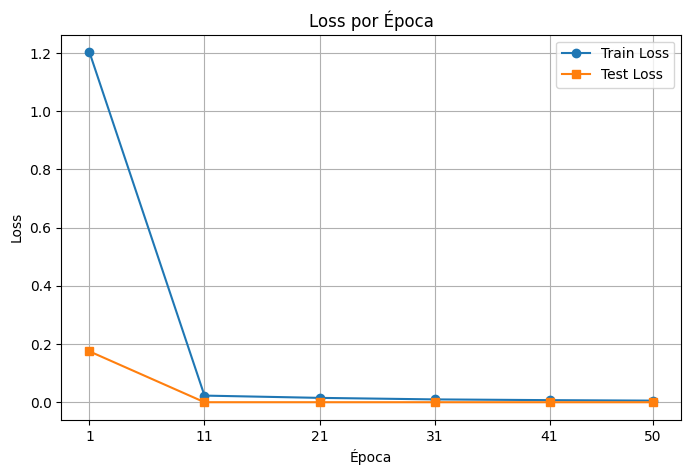

In [ ]:
epochs_recortados = [epochs[i] for i in recortes]
train_loss_recortado = [history["train_loss"][i] for i in recortes]
test_loss_recortado = [history["test_loss"][i] for i in recortes]


plt.figure(figsize=(8, 5))

plt.plot(
    epochs_recortados,
    train_loss_recortado,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_recortados,
    test_loss_recortado,
    marker="s",
    label="Test Loss"
)

plt.xticks(epochs_recortados)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss por Época")
plt.legend()
plt.grid(True)
plt.show()

## Acuracia

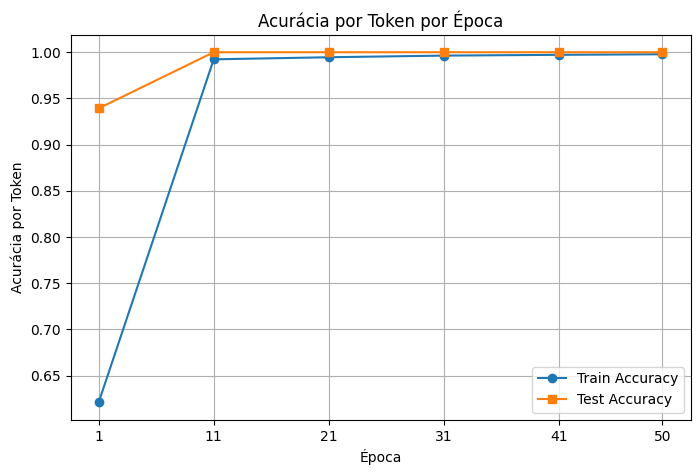

In [198]:
train_acc_recortado = [history["train_acc"][i] for i in recortes]
test_acc_recortado = [history["test_acc"][i] for i in recortes]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_recortados,
    train_acc_recortado,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs_recortados,
    test_acc_recortado,
    marker="s",
    label="Test Accuracy"
)

plt.xticks(epochs_recortados)

plt.xlabel("Época")
plt.ylabel("Acurácia por Token")
plt.title("Acurácia por Token por Época")
plt.legend()
plt.grid(True)
plt.show()

## Exact match

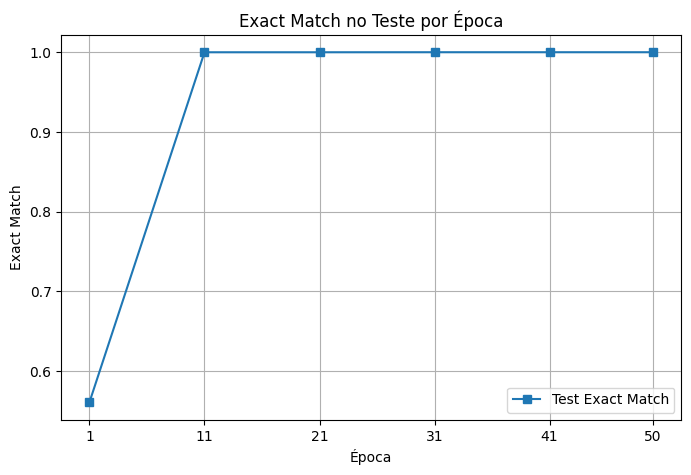

In [199]:
exact_match_recortado = [history["test_exact_match"][i] for i in recortes]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_recortados,
    exact_match_recortado,
    marker="s",
    label="Test Exact Match"
)

plt.xticks(epochs_recortados)

plt.xlabel("Época")
plt.ylabel("Exact Match")
plt.title("Exact Match no Teste por Época")
plt.legend()
plt.grid(True)
plt.show()

# Melhor modelo

In [200]:
checkpoint = torch.load(
    "bestModel.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

final_test_loss, final_test_acc, final_test_exact = evaluate(
    model=model,
    test_loader=test_loader,
    device=device
)

print("RESULTADO FINAL NO TESTE\n")

print(f"Test Loss:        {final_test_loss:.8f}")
print(f"Test Accuracy:    {final_test_acc:.8f} ({final_test_acc * 100:.2f}%)")
print(f"Test Exact Match: {final_test_exact:.8f} ({final_test_exact * 100:.2f}%)")


RESULTADO FINAL NO TESTE

Test Loss:        0.00000026
Test Accuracy:    1.00000000 (100.00%)
Test Exact Match: 1.00000000 (100.00%)


# Inferencia

In [201]:
def encode(text):
    return [stoi[ch] for ch in text]


def decode(tokens):
    return "".join(
        itos[int(token)]
        for token in tokens
        if int(token) != PAD_IDX
    )


def prever_data(entrada):
    entrada = entrada.lower()
    prompt = f"{entrada} => "

    idx = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    saida = model.generate(
        idx,
        max_new_tokens=10
    )

    texto_gerado = decode(saida[0].tolist())

    return texto_gerado


exemplos = [
    "15 de Maio de 2026",
    "01/01/2000",
    "7 de fevereiro de 1988",
    "Dia 23 de Agosto de 2040",
    "21 de dezembro de 2970",
    "12 de abril de 7563",
]

for exemplo in exemplos:
    print(prever_data(exemplo))

15 de maio de 2026 => 2026-05-15
01/01/2000 => 2000-01-01
7 de fevereiro de 1988 => 1988-02-07
dia 23 de agosto de 2040 => 2040-08-23
21 de dezembro de 2970 => 2970-12-21
12 de abril de 7563 => 7563-04-12
